<a href="https://colab.research.google.com/github/savioshaju/MNIST-Image-Classification-with-CNN/blob/main/minist_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST Image Classification with CNN

## 1. Imports and Setup

In [ ]:
cd drive/MyDrive/minist

[Errno 2] No such file or directory: 'drive/MyDrive/minist'
/content/drive/MyDrive/minist


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os # Added for path manipulation
import pandas as pd # Added for classification report DataFrame conversion
import seaborn as sns # Added for confusion matrix visualization
from google.colab import drive # Added for mounting Google Drive

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow Version:", tf.__version__)


(x_train_full, y_train_full), (x_test, y_test) = mnist.load_data()

# Normalize

x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension

x_train_full = np.expand_dims(x_train_full, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# Fixed validation split

x_train = x_train_full[:50000]
y_train = y_train_full[:50000]

x_val = x_train_full[50000:]
y_val = y_train_full[50000:]

print("Train:", x_train.shape)
print("Validation:", x_val.shape)
print("Test:", x_test.shape)

# Mount Google Drive and set up save path
drive.mount('/content/drive')
save_base_path = '/content/drive/MyDrive/mnist_results' # Using a new directory for results
os.makedirs(save_base_path, exist_ok=True)
print(f"Results (images and models) will be saved to: {save_base_path}")

TensorFlow Version: 2.20.0
Train: (50000, 28, 28, 1)
Validation: (10000, 28, 28, 1)
Test: (10000, 28, 28, 1)
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Results (images and models) will be saved to: /content/drive/MyDrive/mnist_results


## 2. Baseline Model

### 2.1 Model Training

In [ ]:
baseline_model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(),

    Flatten(),

    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])

baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_baseline = baseline_model.fit(
    x_train,
    y_train,
    validation_data=(x_val,y_val),
    epochs=10,
    batch_size=128,
    verbose=1
)

baseline_model.evaluate(x_test,y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9313 - loss: 0.2326 - val_accuracy: 0.9783 - val_loss: 0.0747
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9799 - loss: 0.0651 - val_accuracy: 0.9833 - val_loss: 0.0561
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9862 - loss: 0.0452 - val_accuracy: 0.9868 - val_loss: 0.0462
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9900 - loss: 0.0338 - val_accuracy: 0.9887 - val_loss: 0.0419
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9911 - loss: 0.0281 - val_accuracy: 0.9882 - val_loss: 0.0418
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9927 - loss: 0.0238 - val_accuracy: 0.9890 - val_loss: 0.0384
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9948 - loss: 0.0162 - val_accuracy: 0.9885 - val_loss: 0.0438
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9953 - loss: 0.0148 - val_accuracy: 

[0.0366230346262455, 0.9878000020980835]

In [ ]:
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

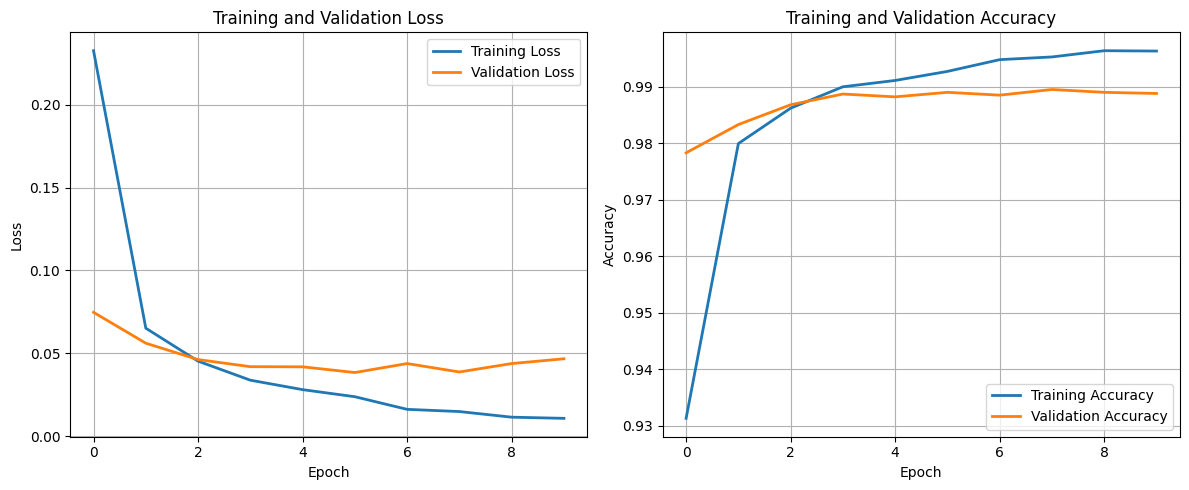

In [ ]:
plt.figure(figsize=(12,5))


plt.subplot(1,2,1)
plt.plot(history_baseline.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history_baseline.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history_baseline.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(save_base_path, 'training_curves_baseline.png')) # Save the figure
plt.show()

In [ ]:
test_loss, test_accuracy = baseline_model.evaluate(x_test, y_test, verbose=0)

print(f"Training Accuracy   : {history_baseline.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy : {history_baseline.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy       : {test_accuracy:.4f}")

print(f"Training Loss       : {history_baseline.history['loss'][-1]:.4f}")
print(f"Validation Loss     : {history_baseline.history['val_loss'][-1]:.4f}")
print(f"Test Loss           : {test_loss:.4f}")

Training Accuracy   : 0.9963
Validation Accuracy : 0.9888
Test Accuracy       : 0.9878
Training Loss       : 0.0107
Validation Loss     : 0.0467
Test Loss           : 0.0366


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


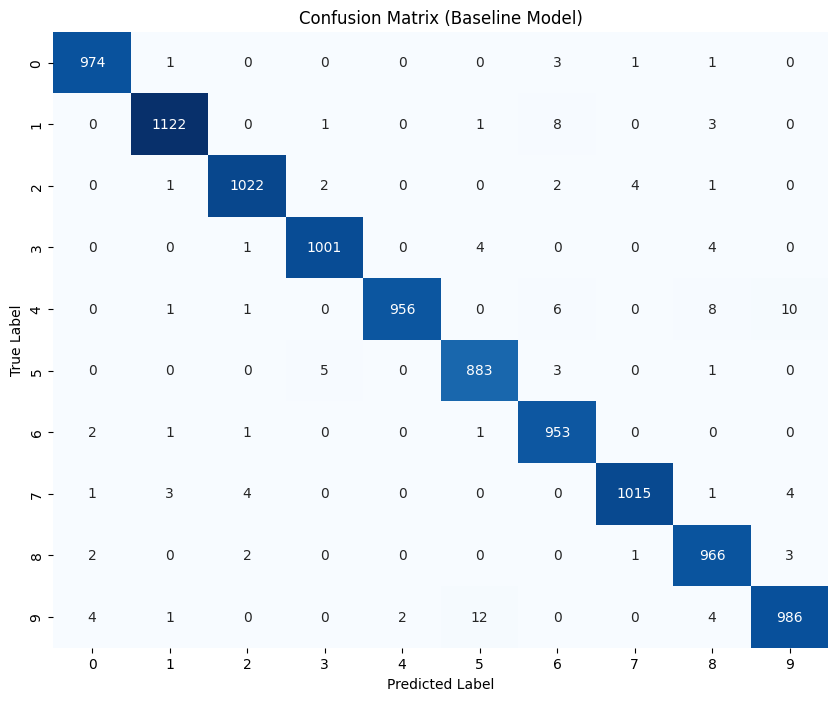

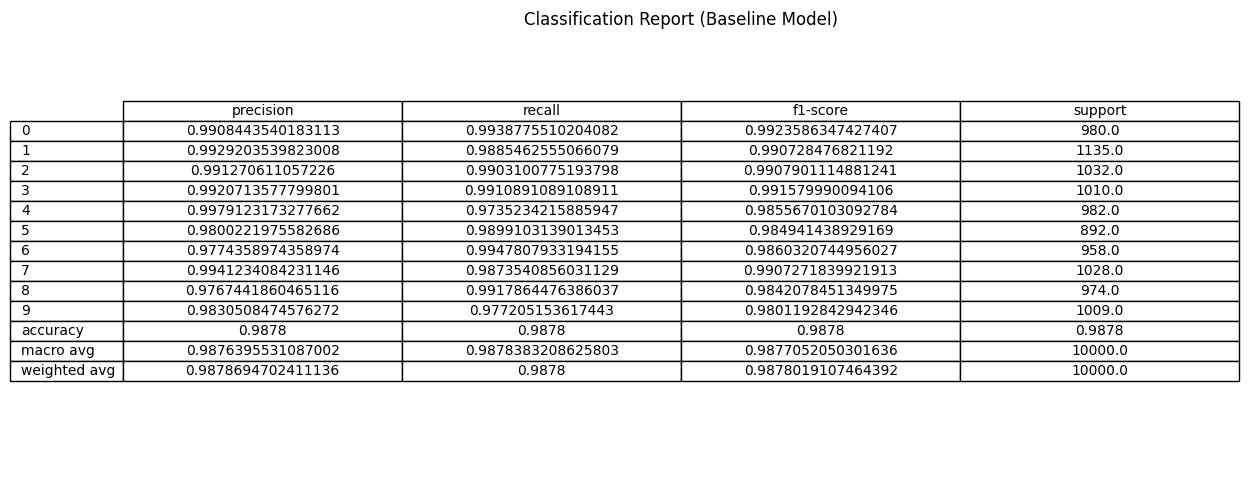

Confusion Matrix (Baseline Model):
[[ 974    1    0    0    0    0    3    1    1    0]
 [   0 1122    0    1    0    1    8    0    3    0]
 [   0    1 1022    2    0    0    2    4    1    0]
 [   0    0    1 1001    0    4    0    0    4    0]
 [   0    1    1    0  956    0    6    0    8   10]
 [   0    0    0    5    0  883    3    0    1    0]
 [   2    1    1    0    0    1  953    0    0    0]
 [   1    3    4    0    0    0    0 1015    1    4]
 [   2    0    2    0    0    0    0    1  966    3]
 [   4    1    0    0    2   12    0    0    4  986]]

Classification Report (Baseline Model):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       1.00      0.97      0.99       982
           5       0.98      0.99      0.98       892
           6  

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# Get predictions for the test set
y_pred_baseline = np.argmax(baseline_model.predict(x_test), axis=1)

# Confusion Matrix
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.title('Confusion Matrix (Baseline Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig(os.path.join(save_base_path, 'confusion_matrix_baseline.png'))
plt.show() # Display the plot in the notebook
plt.close() # Close the figure to free memory

# Classification Report
report_baseline = classification_report(y_test, y_pred_baseline, output_dict=True)
# Convert to DataFrame for better display
df_report_baseline = pd.DataFrame(report_baseline).transpose()

plt.figure(figsize=(12, 6))
ax = plt.gca() # Get current axes
ax.axis('off') # Hide axes
tbl = ax.table(cellText=df_report_baseline.values,
               colLabels=df_report_baseline.columns,
               rowLabels=df_report_baseline.index,
               loc='center',
               cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.2) # Adjust size
plt.title('Classification Report (Baseline Model)', y=0.95) # Adjust title position
plt.savefig(os.path.join(save_base_path, 'classification_report_baseline.png'), bbox_inches='tight')
plt.show() # Display the plot in the notebook
plt.close()

print('Confusion Matrix (Baseline Model):')
print(cm_baseline) # Still print for console output

print('\nClassification Report (Baseline Model):')
print(classification_report(y_test, y_pred_baseline)) # Still print for console output

Sample Predictions (Baseline Model):
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step


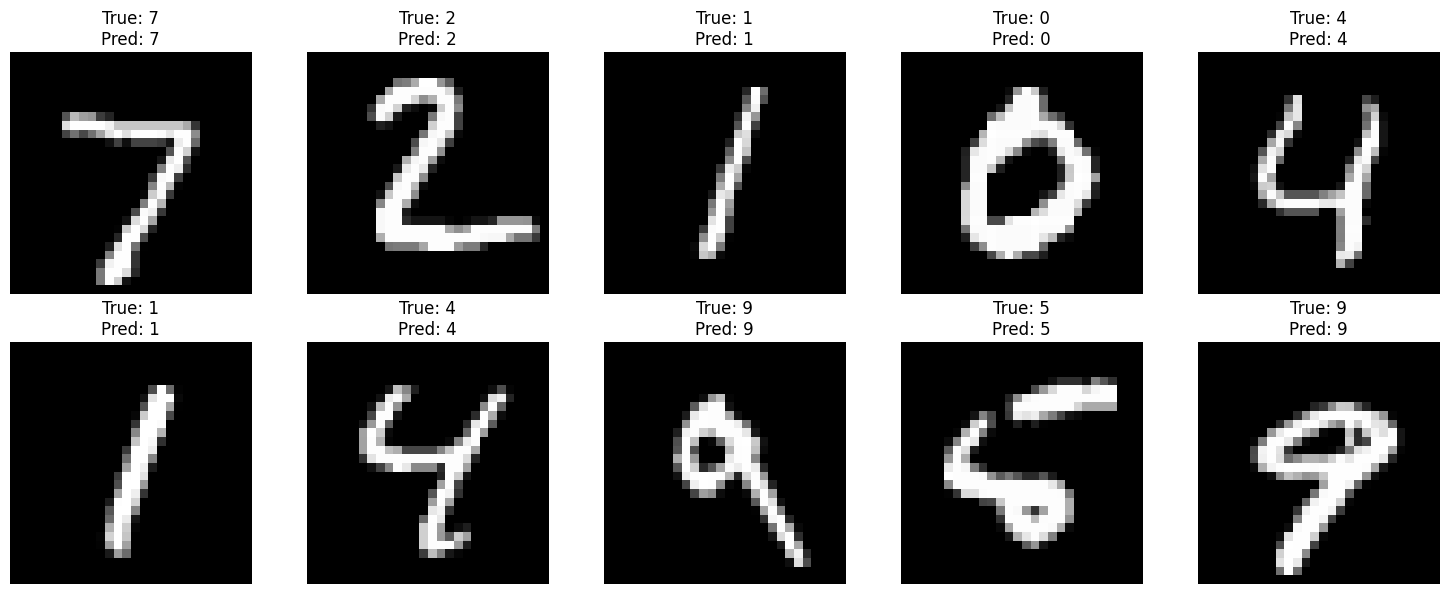

In [ ]:
def plot_predictions(model, x_test, y_test, num_samples=10):
    predictions = np.argmax(model.predict(x_test[:num_samples]), axis=1)
    true_labels = y_test[:num_samples]

    plt.figure(figsize=(15, 6))
    for i in range(num_samples):
        plt.subplot(2, 5, i + 1)
        plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
        plt.title(f'True: {true_labels[i]}\nPred: {predictions[i]}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print('Sample Predictions (Baseline Model):')
plot_predictions(baseline_model, x_test, y_test, num_samples=10)

In [ ]:
cd drive/MyDrive/minist

[Errno 2] No such file or directory: 'drive/MyDrive/minist'
/content/drive/MyDrive/minist


In [ ]:
baseline_model.save("baseline_model.keras")

## 3. Overfitting Model

### 3.1 Model Training (Overfit)

In [ ]:
overfit_model = Sequential([
    tf.keras.Input(shape=(28,28,1)),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(),

    Conv2D(256,(3,3),activation='relu'),
    MaxPooling2D(),

    Flatten(),

    Dense(1024,activation='relu'),
    Dense(512,activation='relu'),

    Dense(10,activation='softmax')
])

overfit_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_overfit = overfit_model.fit(
    x_train,
    y_train,
    validation_data=(x_val,y_val),
    epochs=50,
    batch_size=128,
    verbose=1
)
overfit_model.evaluate(x_test,y_test)

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.9574 - loss: 0.1373 - val_accuracy: 0.9837 - val_loss: 0.0546
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9874 - loss: 0.0398 - val_accuracy: 0.9887 - val_loss: 0.0377
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9912 - loss: 0.0254 - val_accuracy: 0.9890 - val_loss: 0.0447
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9944 - loss: 0.0173 - val_accuracy: 0.9904 - val_loss: 0.0356
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9957 - loss: 0.0132 - val_accuracy: 0.9906 - val_loss: 0.0417
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9957 - loss: 0.0124 - val_accuracy: 0.9879 - val_loss: 0.0557
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9968 - loss: 0.0091 - val_accuracy: 0.9910 - val_loss: 0.0456
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9970 - loss: 0.0099 - val_ac

[0.04582231491804123, 0.9936000108718872]

In [ ]:
overfit_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │     6,554,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,143,008 (84.47 MB)

 Trainable params: 7,381,002 (28.16 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 14,762,006 (56.31 MB)

In [ ]:
test_loss, test_accuracy = overfit_model.evaluate(x_test, y_test, verbose=0)

print(f"Training Accuracy   : {history_overfit.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy : {history_overfit.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy       : {test_accuracy:.4f}")

print(f"Training Loss       : {history_overfit.history['loss'][-1]:.4f}")
print(f"Validation Loss     : {history_overfit.history['val_loss'][-1]:.4f}")
print(f"Test Loss           : {test_loss:.4f}")

Training Accuracy   : 1.0000
Validation Accuracy : 0.9942
Test Accuracy       : 0.9936
Training Loss       : 0.0000
Validation Loss     : 0.0649
Test Loss           : 0.0458


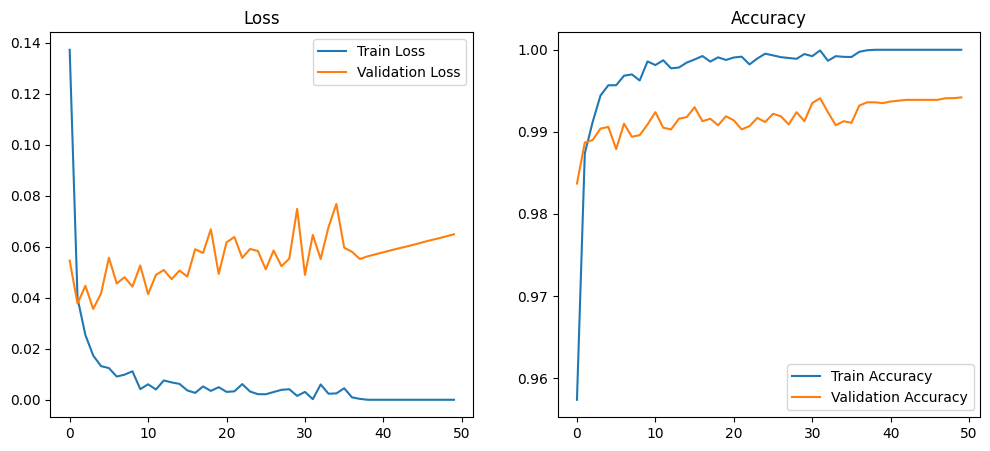

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_overfit.history['loss'], label='Train Loss')
plt.plot(history_overfit.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history_overfit.history['accuracy'], label='Train Accuracy')
plt.plot(history_overfit.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

plt.savefig(os.path.join(save_base_path, 'training_curves_overfit.png')) # Save the figure
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


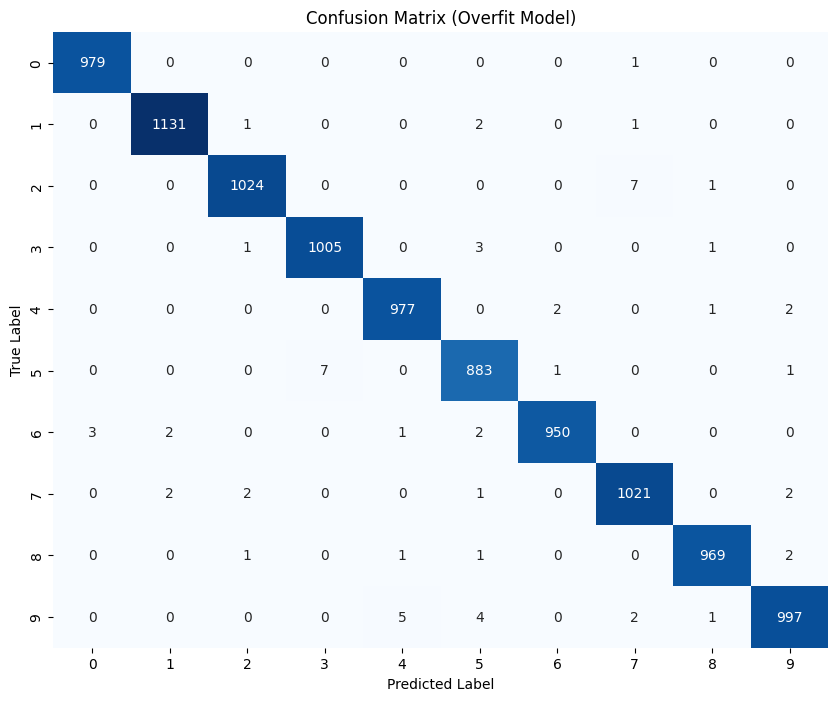

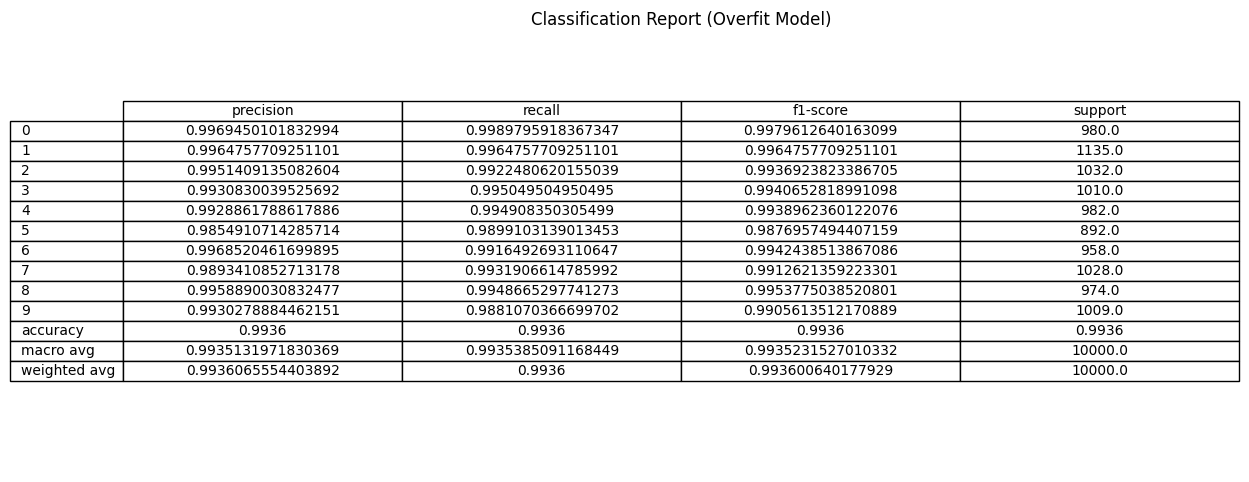

Confusion Matrix (Overfit Model):
[[ 979    0    0    0    0    0    0    1    0    0]
 [   0 1131    1    0    0    2    0    1    0    0]
 [   0    0 1024    0    0    0    0    7    1    0]
 [   0    0    1 1005    0    3    0    0    1    0]
 [   0    0    0    0  977    0    2    0    1    2]
 [   0    0    0    7    0  883    1    0    0    1]
 [   3    2    0    0    1    2  950    0    0    0]
 [   0    2    2    0    0    1    0 1021    0    2]
 [   0    0    1    0    1    1    0    0  969    2]
 [   0    0    0    0    5    4    0    2    1  997]]

Classification Report (Overfit Model):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       1.00      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6    

In [ ]:
y_pred_overfit = np.argmax(overfit_model.predict(x_test), axis=1)

# Confusion Matrix
cm_overfit = confusion_matrix(y_test, y_pred_overfit)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_overfit, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.title('Confusion Matrix (Overfit Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig(os.path.join(save_base_path, 'confusion_matrix_overfit.png'))
plt.show()
plt.close()

# Classification Report
report_overfit = classification_report(y_test, y_pred_overfit, output_dict=True)
df_report_overfit = pd.DataFrame(report_overfit).transpose()

plt.figure(figsize=(12, 6))
ax = plt.gca()
ax.axis('off')
tbl = ax.table(cellText=df_report_overfit.values,
               colLabels=df_report_overfit.columns,
               rowLabels=df_report_overfit.index,
               loc='center',
               cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.2)
plt.title('Classification Report (Overfit Model)', y=0.95)
plt.savefig(os.path.join(save_base_path, 'classification_report_overfit.png'), bbox_inches='tight')
plt.show()
plt.close()

print('Confusion Matrix (Overfit Model):')
print(cm_overfit)

print('\nClassification Report (Overfit Model):')
print(classification_report(y_test, y_pred_overfit))

In [ ]:
overfit_model.save(os.path.join(save_base_path, "overfit_model.keras"))
print(f"Overfit model saved to {os.path.join(save_base_path, 'overfit_model.keras')}")

Overfit model saved to /content/drive/MyDrive/mnist_results/overfit_model.keras


Sample Predictions (Overfit Model):
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step


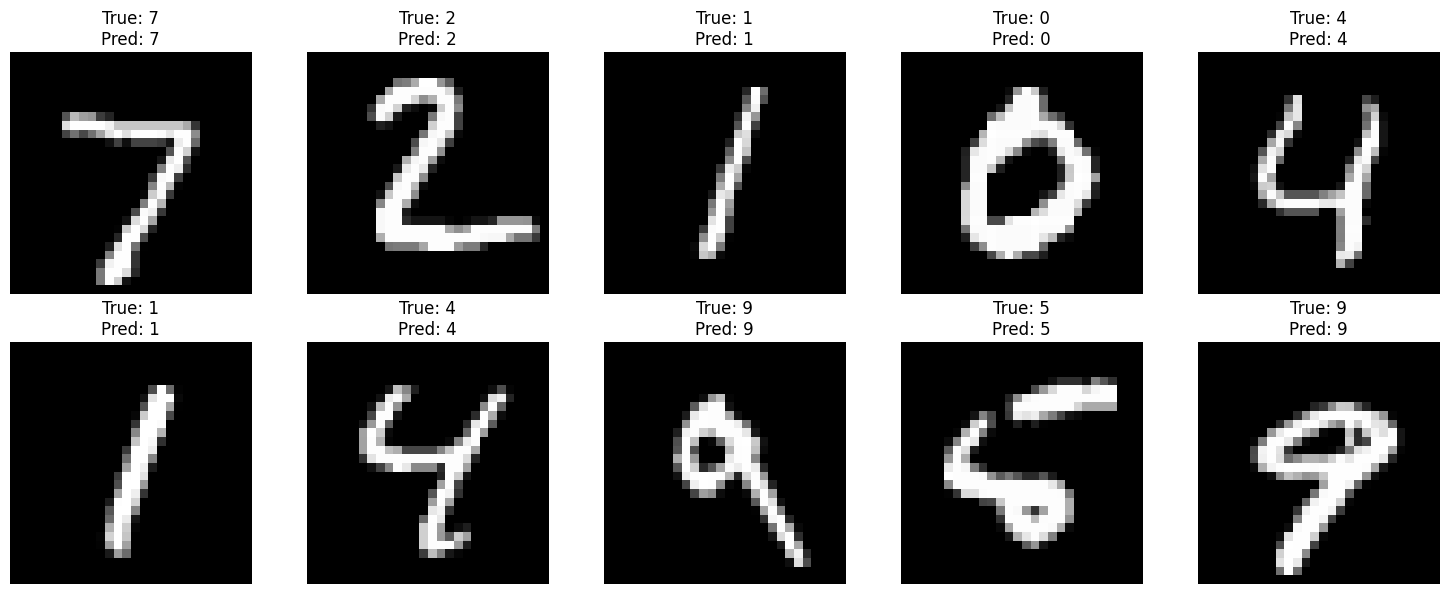

In [ ]:
print('Sample Predictions (Overfit Model):')
plot_predictions(overfit_model, x_test, y_test, num_samples=10)

## 4. Regularized Model

### 4.1 Model Training (Regularized)

In [ ]:
same_arch_model = Sequential([
    tf.keras.Input(shape=(28,28,1)),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(),

    Conv2D(256,(3,3),activation='relu'),
    MaxPooling2D(),

    Flatten(),

    Dense(1024,activation='relu'),
    Dense(512,activation='relu'),

    Dense(10,activation='softmax')
])

same_arch_model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=0.001,
        weight_decay=1e-4
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(

    ),
    metrics=['accuracy']
)

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

datagen.fit(x_train)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3
)

history_fixed = same_arch_model.fit(
    datagen.flow(x_train,y_train,batch_size=128),
    validation_data=(x_val,y_val),
    epochs=50,
    callbacks=[early_stop,reduce_lr],
    verbose=1
)

same_arch_model.evaluate(x_test,y_test)

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 55ms/step - accuracy: 0.9199 - loss: 0.2506 - val_accuracy: 0.9805 - val_loss: 0.0614 - learning_rate: 0.0010
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.9772 - loss: 0.0717 - val_accuracy: 0.9893 - val_loss: 0.0366 - learning_rate: 0.0010
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.9812 - loss: 0.0595 - val_accuracy: 0.9919 - val_loss: 0.0300 - learning_rate: 0.0010
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.9845 - loss: 0.0493 - val_accuracy: 0.9920 - val_loss: 0.0303 - learning_rate: 0.0010
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.9868 - loss: 0.0426 - val_accuracy: 0.9918 - val_loss: 0.0297 - learning_rate: 0.0010
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.9889 - loss: 0.0379 - val_accuracy: 0.9925 - val_loss: 0.0254 - learning_rate: 0.0010
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.9886 - l

[0.016334209591150284, 0.994700014591217]

In [ ]:
same_arch_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1024)           │     6,554,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,143,008 (84.47 MB)

 Trainable params: 7,381,002 (28.16 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 14,762,006 (56.31 MB)

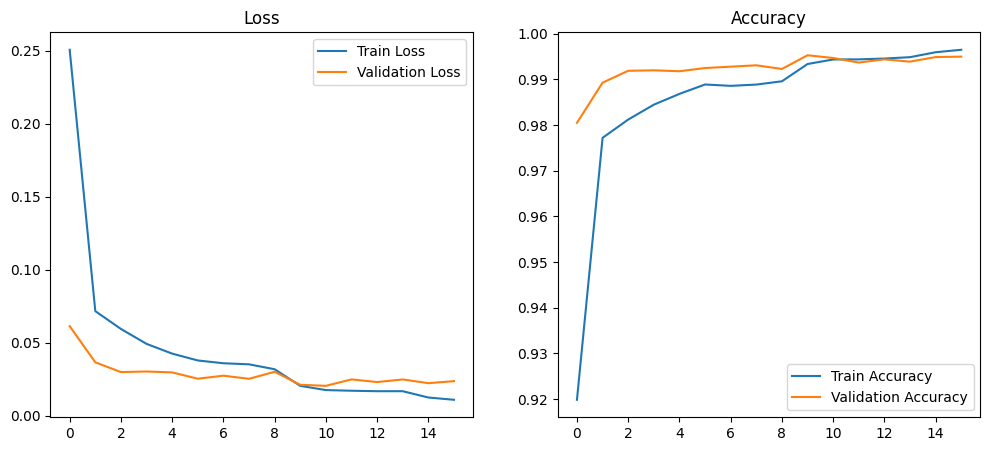

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_fixed.history['loss'], label='Train Loss')
plt.plot(history_fixed.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history_fixed .history['accuracy'], label='Train Accuracy')
plt.plot(history_fixed.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

plt.savefig(os.path.join(save_base_path, 'training_curves_regularized.png')) # Save the figure
plt.show()

In [ ]:
test_loss, test_accuracy = same_arch_model.evaluate(x_test, y_test, verbose=0)

print(f"Training Accuracy   : {history_fixed.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy : {history_fixed.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy       : {test_accuracy:.4f}")

print(f"Training Loss       : {history_fixed.history['loss'][-1]:.4f}")
print(f"Validation Loss     : {history_fixed.history['val_loss'][-1]:.4f}")
print(f"Test Loss           : {test_loss:.4f}")

Training Accuracy   : 0.9965
Validation Accuracy : 0.9950
Test Accuracy       : 0.9947
Training Loss       : 0.0110
Validation Loss     : 0.0237
Test Loss           : 0.0163


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


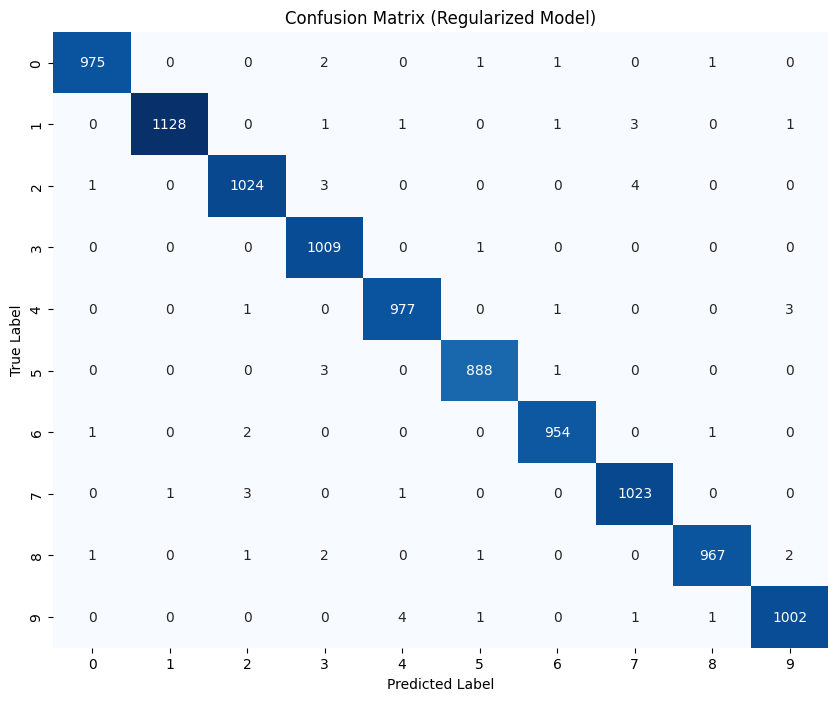

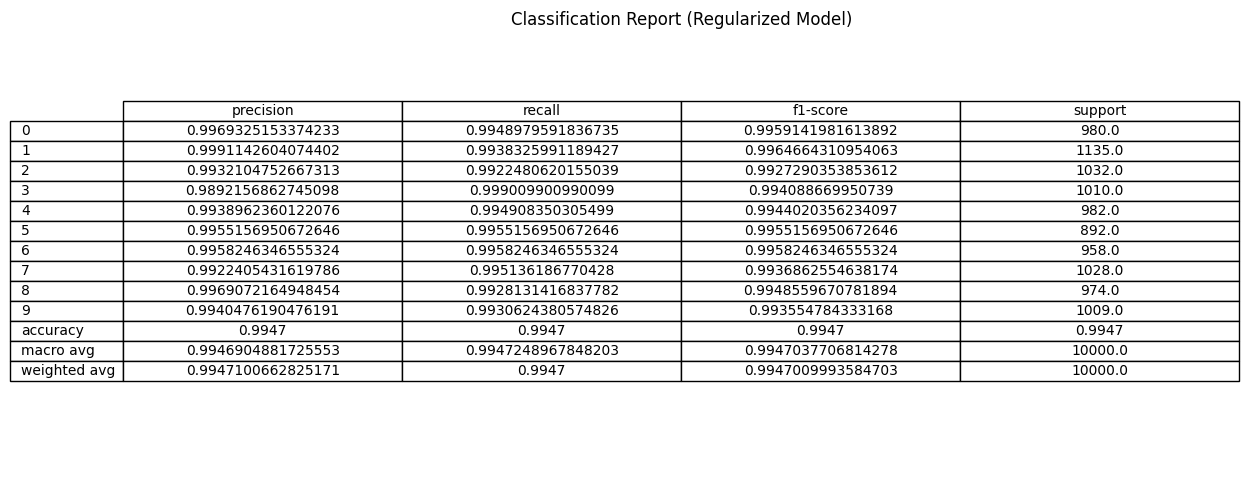

Confusion Matrix (Regularized Model):
[[ 975    0    0    2    0    1    1    0    1    0]
 [   0 1128    0    1    1    0    1    3    0    1]
 [   1    0 1024    3    0    0    0    4    0    0]
 [   0    0    0 1009    0    1    0    0    0    0]
 [   0    0    1    0  977    0    1    0    0    3]
 [   0    0    0    3    0  888    1    0    0    0]
 [   1    0    2    0    0    0  954    0    1    0]
 [   0    1    3    0    1    0    0 1023    0    0]
 [   1    0    1    2    0    1    0    0  967    2]
 [   0    0    0    0    4    1    0    1    1 1002]]

Classification Report (Regularized Model):
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       980
           1       1.00      0.99      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       1.00      1.00      1.00       892
        

In [ ]:
y_pred_fixed = np.argmax(same_arch_model.predict(x_test), axis=1)

# Confusion Matrix
cm_fixed = confusion_matrix(y_test, y_pred_fixed)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_fixed, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.title('Confusion Matrix (Regularized Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig(os.path.join(save_base_path, 'confusion_matrix_regularized.png'))
plt.show()
plt.close()

# Classification Report
report_fixed = classification_report(y_test, y_pred_fixed, output_dict=True)
df_report_fixed = pd.DataFrame(report_fixed).transpose()

plt.figure(figsize=(12, 6))
ax = plt.gca()
ax.axis('off')
tbl = ax.table(cellText=df_report_fixed.values,
               colLabels=df_report_fixed.columns,
               rowLabels=df_report_fixed.index,
               loc='center',
               cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.2)
plt.title('Classification Report (Regularized Model)', y=0.95)
plt.savefig(os.path.join(save_base_path, 'classification_report_regularized.png'), bbox_inches='tight')
plt.show()
plt.close()

print('Confusion Matrix (Regularized Model):')
print(cm_fixed)

print('\nClassification Report (Regularized Model):')
print(classification_report(y_test, y_pred_fixed))

Sample Predictions (Regularized Model):
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step


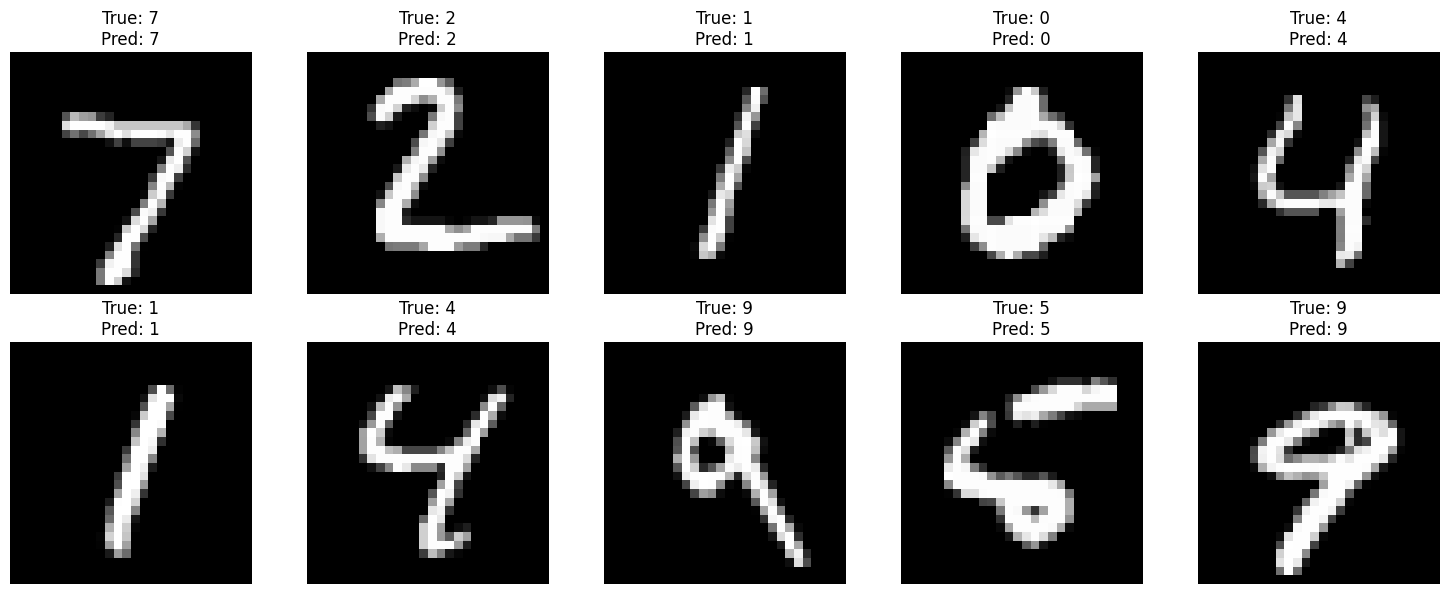

In [ ]:
print('Sample Predictions (Regularized Model):')
plot_predictions(same_arch_model, x_test, y_test, num_samples=10)

In [ ]:
same_arch_model.save("same_arch_model.keras")

In [ ]:
ls

baseline_model.keras  same_arch_model.keras
